# Feature Engineering cho Dự đoán Điểm Thực hành Sinh viên

## Mục tiêu
Dựa vào dữ liệu từ online judge, chúng ta sẽ trích xuất các đặc trưng phản ánh:
- Độ chăm chỉ của sinh viên
- Khả năng giải quyết bài khó
- Thời gian học tập hiệu quả
- Chất lượng code và tiến trình học

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Load và Preprocessing Dữ liệu

In [2]:
# Load dữ liệu
annonimized = pd.read_csv('annonimized.csv')
qt = pd.read_csv('qt-public.csv')

In [3]:

df = annonimized.copy()
df.columns = [
    "assignment_id", "problem_id", "student", "is_final", "status", 
    "pre_score", "coefficient", "language_id", "created_at", "updated_at", "judgement"
]

df['created_at'] = pd.to_datetime(df['created_at'], format='%m-%d %H:%M:%S', errors='coerce')
df['updated_at'] = pd.to_datetime(df['updated_at'], format='%m-%d %H:%M:%S', errors='coerce')

def parse_judgement(judgement_str):
    try:
        judgement = json.loads(judgement_str)
        return {
            'avg_time': np.mean(judgement.get('times', [0])),
            'avg_memory': np.mean(judgement.get('mems', [0])),
            'total_wrong': judgement.get('verdicts', {}).get('WRONG', 0),
            'total_tle': judgement.get('verdicts', {}).get('Time Limit Exceeded', 0),
            'total_runtime_error': judgement.get('verdicts', {}).get('Runtime Error', 0),
        }
    except:
        return {
            'avg_time': 0, 'avg_memory': 0, 'total_wrong': 0, 
            'total_tle': 0, 'total_runtime_error': 0
        }

judgement_features = df['judgement'].apply(parse_judgement)
judgement_df = pd.DataFrame(list(judgement_features))
df = pd.concat([df, judgement_df], axis=1)

df

,assignment_id,problem_id,student,is_final,status,pre_score,coefficient,language_id,created_at,updated_at,judgement,avg_time,avg_memory,total_wrong,total_tle,total_runtime_error
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:02:04,1900-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,10,0,0
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:04:41,1900-10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,10,0,0
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:06:49,1900-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:47:52,1900-10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 09:19:35,1900-10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295193,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,388516cbf597351226be1bdbe5ef30b9dcef570f,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:03:43,1900-01-15 16:03:53,"{""times"":[0,0,0,0,0,0,0,0,0,0,0,0,0,0],""mems"":...",0.0,0.0,0,0,0
295194,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,d2b96124ccb8e27b4b8dacdb935e729cb1ba546b,232cce96362898f08e9150ba244adaf2d6583ab2,0,Compilation Error,0,100,it0012,1900-01-15 16:04:07,1900-01-15 16:05:08,"{""times"":[],""mems"":[],""verdicts"":{""\n\nIn func...",NaN,NaN,0,0,0
295195,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,d2b96124ccb8e27b4b8dacdb935e729cb1ba546b,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:04:58,1900-01-15 16:05:08,"{""times"":[0,0,0,0,0,0,0,0,0,0,0,0,0,0],""mems"":...",0.0,0.0,0,0,0
295196,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,8c0f8dd4ff55e1609f733e043ac5e88b1dde6e7c,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:05:13,1900-01-15 16:05:22,"{""times"":[0,0,0,0,0,0,0,0,0,0,0,0,0],""mems"":[0...",0.0,0.0,0,0,0


## 2. Feature Engineering - Các Đặc trưng Nâng cao

### A. Đặc trưng về Độ chăm chỉ

In [4]:
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek  # 0=Monday, 6=Sunday
df['processing_time'] = (df['updated_at'] - df['created_at']).dt.total_seconds()

def categorize_work_time(hour):
    if 6 <= hour <= 18:
        return 'day_time'
    elif 19 <= hour <= 23:
        return 'evening'
    else:
        return 'late_night'

df['work_time_category'] = df['hour'].apply(categorize_work_time)

course_start = df['created_at'].min()
df['days_from_start'] = (df['created_at'] - course_start).dt.days

### B. Đặc trưng về Khả năng giải quyết bài khó

In [5]:
# Tính độ khó của bài tập dựa trên tỷ lệ AC (Accepted)
problem_difficulty = df.groupby('problem_id').agg({
    'pre_score': lambda x: (x == 10000).mean(),  # Tỷ lệ AC
    'student': 'nunique'  # Số sinh viên thử làm
}).rename(columns={'pre_score': 'problem_ac_rate', 'student': 'problem_attempts'})

problem_difficulty['problem_difficulty'] = 1 - problem_difficulty['problem_ac_rate']

df = df.merge(problem_difficulty, left_on='problem_id', right_index=True, how='left')

print("Đã tính độ khó bài tập!")
print(f"Bài khó nhất có tỷ lệ AC: {problem_difficulty['problem_ac_rate'].min():.3f}")
print(f"Bài dễ nhất có tỷ lệ AC: {problem_difficulty['problem_ac_rate'].max():.3f}")

df

Đã tính độ khó bài tập!
Bài khó nhất có tỷ lệ AC: 0.000
Bài dễ nhất có tỷ lệ AC: 1.000


,assignment_id,problem_id,student,is_final,status,pre_score,coefficient,language_id,created_at,updated_at,...,total_tle,total_runtime_error,hour,day_of_week,processing_time,work_time_category,days_from_start,problem_ac_rate,problem_attempts,problem_difficulty
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:02:04,1900-10-09 08:06:58,...,0,0,8.0,1.0,294.0,day_time,281.0,0.274157,928,0.725843
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:04:41,1900-10-09 08:04:51,...,0,0,8.0,1.0,10.0,day_time,281.0,0.274157,928,0.725843
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:06:49,1900-10-09 08:06:58,...,0,0,8.0,1.0,9.0,day_time,281.0,0.274157,928,0.725843
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:47:52,1900-10-09 08:48:01,...,0,0,8.0,1.0,9.0,day_time,281.0,0.277803,1097,0.722197
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 09:19:35,1900-10-09 09:19:45,...,0,0,9.0,1.0,10.0,day_time,281.0,0.216028,1157,0.783972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295193,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,388516cbf597351226be1bdbe5ef30b9dcef570f,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:03:43,1900-01-15 16:03:53,...,0,0,16.0,0.0,10.0,day_time,14.0,0.332190,650,0.667810
295194,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,d2b96124ccb8e27b4b8dacdb935e729cb1ba546b,232cce96362898f08e9150ba244adaf2d6583ab2,0,Compilation Error,0,100,it0012,1900-01-15 16:04:07,1900-01-15 16:05:08,...,0,0,16.0,0.0,61.0,day_time,14.0,0.399650,660,0.600350
295195,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,d2b96124ccb8e27b4b8dacdb935e729cb1ba546b,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:04:58,1900-01-15 16:05:08,...,0,0,16.0,0.0,10.0,day_time,14.0,0.399650,660,0.600350
295196,613aea04c978f5e72fffc8bcff1f7b695a63f7b1,8c0f8dd4ff55e1609f733e043ac5e88b1dde6e7c,232cce96362898f08e9150ba244adaf2d6583ab2,1,SCORE,10000,100,it0012,1900-01-15 16:05:13,1900-01-15 16:05:22,...,0,0,16.0,0.0,9.0,day_time,14.0,0.458498,564,0.541502


### C. Feature Engineering cho từng Sinh viên

In [6]:
def extract_student_features(df):
    """Trích xuất đặc trưng cho từng sinh viên"""
    
    student_features = []
    
    for student in df['student'].unique():
        student_data = df[df['student'] == student].copy()
        
        features = {'student': student}
        
        # === BASIC FEATURES ===
        features['total_submissions'] = len(student_data)
        features['unique_problems'] = student_data['problem_id'].nunique()
        features['unique_assignments'] = student_data['assignment_id'].nunique()
        features['final_submissions'] = student_data['is_final'].sum()
        
        # === PERFORMANCE FEATURES ===
        features['avg_score'] = student_data['pre_score'].mean()
        features['max_score'] = student_data['pre_score'].max()
        features['perfect_scores'] = (student_data['pre_score'] == 10000).sum()
        features['perfect_score_rate'] = features['perfect_scores'] / features['total_submissions']
        features['successful_submissions'] = (student_data['status'] == 'SCORE').sum()
        features['success_rate'] = features['successful_submissions'] / features['total_submissions']
        
        # === EFFORT & PERSISTENCE FEATURES ===
        features['avg_attempts_per_problem'] = features['total_submissions'] / max(features['unique_problems'], 1)
        features['late_submissions'] = (student_data['coefficient'] < 100).sum()
        features['late_submission_rate'] = features['late_submissions'] / features['total_submissions']
        features['avg_processing_time'] = student_data['processing_time'].mean()
        
        # === DIFFICULTY FEATURES ===
        features['avg_problem_difficulty'] = student_data['problem_difficulty'].mean()
        features['max_problem_difficulty'] = student_data['problem_difficulty'].max()
        hard_problems = student_data[student_data['problem_difficulty'] > 0.7]  # Bài khó
        features['hard_problems_attempted'] = len(hard_problems)
        features['hard_problems_solved'] = (hard_problems['pre_score'] == 10000).sum()
        features['hard_problem_success_rate'] = (
            features['hard_problems_solved'] / max(features['hard_problems_attempted'], 1)
        )
        
        # === TIME PATTERN FEATURES (Tính chăm chỉ) ===
        features['late_night_submissions'] = (student_data['work_time_category'] == 'late_night').sum()  # Sửa: thêm ()
        features['weekend_submissions'] = (student_data['day_of_week'].isin([5, 6])).sum()
        features['late_night_rate'] = features['late_night_submissions'] / features['total_submissions']
        features['weekend_rate'] = features['weekend_submissions'] / features['total_submissions']
        
        # Consistency - Tính đều đặn trong học tập
        daily_submissions = student_data.groupby(student_data['created_at'].dt.date).size()
        features['active_days'] = len(daily_submissions)
        features['max_daily_submissions'] = daily_submissions.max() if len(daily_submissions) > 0 else 0
        features['avg_daily_submissions'] = daily_submissions.mean() if len(daily_submissions) > 0 else 0
        features['consistency_score'] = features['active_days'] / max(student_data['days_from_start'].max(), 1)
        
        # === ERROR ANALYSIS FEATURES ===
        features['avg_wrong_answers'] = student_data['total_wrong'].mean()
        features['avg_tle'] = student_data['total_tle'].mean()
        features['avg_runtime_errors'] = student_data['total_runtime_error'].mean()
        
        # === PROGRESSION FEATURES ===
        # # Cải thiện theo thời gian
        # if len(student_data) >= 10:  # Chỉ tính cho sinh viên có đủ dữ liệu
        #     early_scores = student_data.head(len(student_data)//2)['pre_score'].mean()
        #     late_scores = student_data.tail(len(student_data)//2)['pre_score'].mean()
        #     features['score_improvement'] = late_scores - early_scores
        # else:
        #     features['score_improvement'] = 0
            
        # === EFFICIENCY FEATURES ===
        features['avg_execution_time'] = student_data['avg_time'].mean()
        features['avg_memory_usage'] = student_data['avg_memory'].mean()
        
        # # First submission success rate (tỷ lệ AC ngay lần đầu)
        # first_attempts = student_data.groupby('problem_id').first()
        # features['first_attempt_success_rate'] = (first_attempts['pre_score'] == 10000).mean()
        
        student_features.append(features)
    
    return pd.DataFrame(student_features)

# Tạo features cho tất cả sinh viên
print("Đang trích xuất features cho sinh viên...")
student_features_df = extract_student_features(df)
print(f"Đã tạo {len(student_features_df.columns)-1} features cho {len(student_features_df)} sinh viên")

# Hiển thị các features đã tạo
print("\nCác features đã tạo:")
for i, col in enumerate(student_features_df.columns[1:], 1):
    print(f"{i:2d}. {col}")

Đang trích xuất features cho sinh viên...
Đã tạo 32 features cho 1489 sinh viên

Các features đã tạo:
 1. total_submissions
 2. unique_problems
 3. unique_assignments
 4. final_submissions
 5. avg_score
 6. max_score
 7. perfect_scores
 8. perfect_score_rate
 9. successful_submissions
10. success_rate
11. avg_attempts_per_problem
12. late_submissions
13. late_submission_rate
14. avg_processing_time
15. avg_problem_difficulty
16. max_problem_difficulty
17. hard_problems_attempted
18. hard_problems_solved
19. hard_problem_success_rate
20. late_night_submissions
21. weekend_submissions
22. late_night_rate
23. weekend_rate
24. active_days
25. max_daily_submissions
26. avg_daily_submissions
27. consistency_score
28. avg_wrong_answers
29. avg_tle
30. avg_runtime_errors
31. avg_execution_time
32. avg_memory_usage


## 3. Phân tích Correlation và Feature Importance

In [7]:
# Merge với điểm thực hành
qt['diemqt'] = pd.to_numeric(qt['diemqt'], errors='coerce')
final_df = student_features_df.merge(qt[['hash', 'diemqt']], left_on='student', right_on='hash', how='left')
final_df = final_df.drop(columns=['hash'])

# Chia thành có điểm và chưa có điểm
graded_df = final_df[final_df['diemqt'].notna()].copy()
ungraded_df = final_df[final_df['diemqt'].isna()].copy()

print(f"Số sinh viên có điểm: {len(graded_df)}")
print(f"Số sinh viên chưa có điểm: {len(ungraded_df)}")

Số sinh viên có điểm: 754
Số sinh viên chưa có điểm: 735


## 4. Model Training với Multiple Algorithms

In [8]:
X = graded_df.drop(columns=['student', 'diemqt'])
y = graded_df['diemqt']

# Handle infinite values and NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

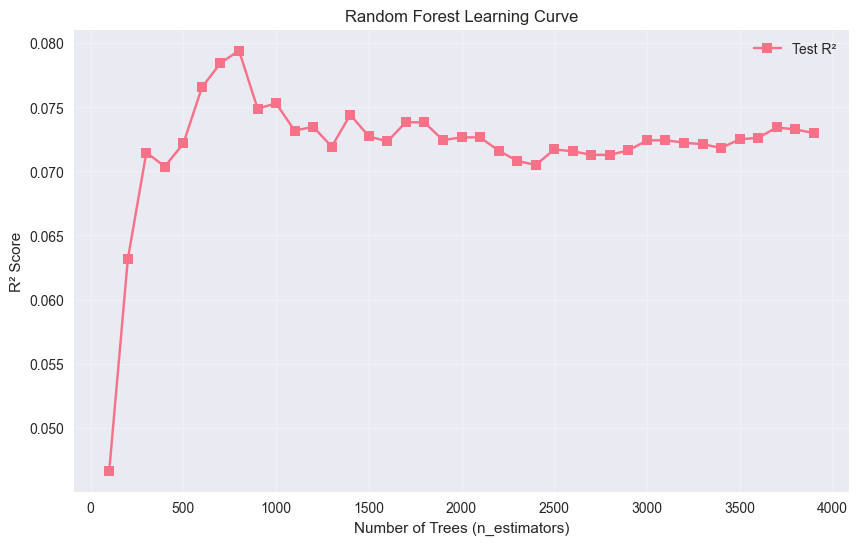

In [9]:
train_scores = []
test_scores = []
best_rf_models = {}
n_estimators_range = range(100, 4000, 100)

for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_test_pred = rf.predict(X_test)
    test_scores.append(r2_score(y_test, y_test_pred))
    best_rf_models[n] = rf

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, test_scores, label='Test R²', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R² Score')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Tìm model Random Forest có R^2 lớn nhất
best_idx = np.argmax(test_scores)
best_n_estimators = list(best_rf_models.keys())[best_idx]
best_rf = best_rf_models[best_n_estimators]
print(f"Best Random Forest n_estimators: {best_n_estimators}, R²: {test_scores[best_idx]:.4f}")

Best Random Forest n_estimators: 800, R²: 0.0794


In [20]:
# Train multiple models
models = {
    'Random Forest': best_rf,
}

results = {}

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'mse': mse,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {np.sqrt(mse):.4f}")
    print()

# Chọn model tốt nhất
best_model_name = max(results.keys(), key=lambda x: results[x]['r2'])
best_model = results[best_model_name]['model']

print(f"Model tốt nhất: {best_model_name} (R² = {results[best_model_name]['r2']:.4f})")

Random Forest:
  R² Score: 0.0794
  MSE: 2.5818
  RMSE: 1.6068

Model tốt nhất: Random Forest (R² = 0.0794)


## 5. Feature Importance Analysis

TOP 15 FEATURES QUAN TRỌNG NHẤT (Random Forest):
 1. max_problem_difficulty              : 0.0823
 2. success_rate                        : 0.0803
 3. unique_assignments                  : 0.0689
 4. avg_daily_submissions               : 0.0621
 5. avg_memory_usage                    : 0.0472
 6. avg_wrong_answers                   : 0.0432
 7. perfect_score_rate                  : 0.0413
 8. avg_problem_difficulty              : 0.0382
 9. hard_problems_solved                : 0.0359
10. avg_processing_time                 : 0.0333
11. perfect_scores                      : 0.0318
12. final_submissions                   : 0.0309
13. max_daily_submissions               : 0.0306
14. avg_attempts_per_problem            : 0.0306
15. avg_score                           : 0.0305


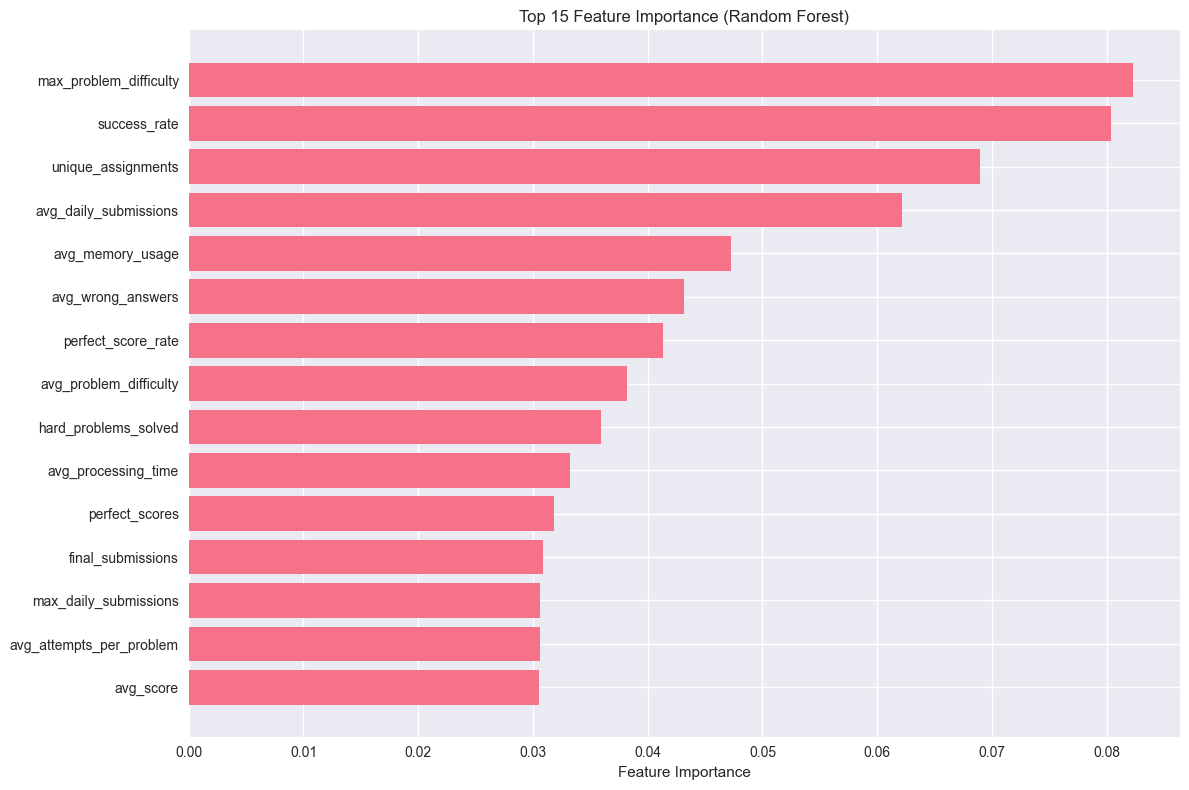

In [21]:
# Feature importance cho Random Forest
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("TOP 15 FEATURES QUAN TRỌNG NHẤT (Random Forest):")
    print("=" * 60)
    for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
        print(f"{i:2d}. {row['feature']:<35} : {row['importance']:.4f}")
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_15_features = feature_importance.head(15)
    plt.barh(range(len(top_15_features)), top_15_features['importance'])
    plt.yticks(range(len(top_15_features)), top_15_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Feature Importance (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6. Predictions và Kết quả

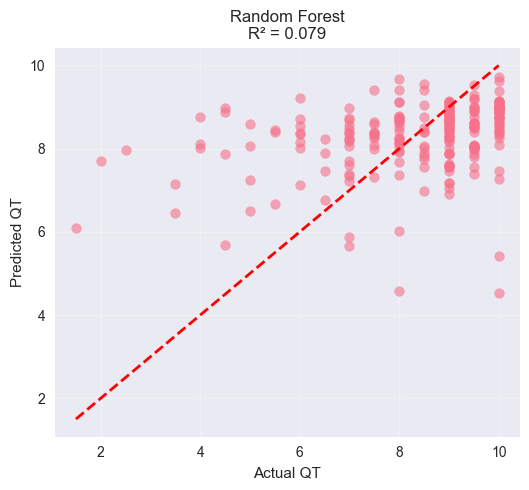

In [22]:
# Visualization: Predicted vs Actual
plt.figure(figsize=(15, 5))

for i, (name, result) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, result['predictions'], alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual QT')
    plt.ylabel('Predicted QT')
    plt.title(f'{name}\nR² = {result["r2"]:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Dự đoán cho sinh viên chưa có điểm
if len(ungraded_df) > 0:
    X_ungraded = ungraded_df.drop(columns=['student', 'diemqt'])
    X_ungraded = X_ungraded.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    if best_model_name == 'Linear Regression':
        X_ungraded_scaled = scaler.transform(X_ungraded)
        predictions = best_model.predict(X_ungraded_scaled)
    else:
        predictions = best_model.predict(X_ungraded)
    
    # Tạo DataFrame kết quả
    prediction_results = pd.DataFrame({
        'student': ungraded_df['student'],
        'predicted_diemqt': predictions
    })
    
    # Lưu kết quả
    prediction_results.to_csv('enhanced_predicted_qt.csv', index=False)

    print("\n Đã lưu kết quả vào 'enhanced_predicted_qt.csv'")
    


 Đã lưu kết quả vào 'enhanced_predicted_qt.csv'


## 7. Phân tích và Kết luận

In [14]:
print("=" * 80)
print("                    PHÂN TÍCH KẾT QUẢ                 ")
print("=" * 80)

print("\n CÁC ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
print("-" * 40)
if 'Random Forest' in results:
    top_5_features = feature_importance.head(5)
    for i, (_, row) in enumerate(top_5_features.iterrows(), 1):
        print(f"{i}. {row['feature']} (importance: {row['importance']:.3f})")

print("\n HIỆU SUẤT MODEL:")
print("-" * 20)
for name, result in results.items():
    print(f"{name}: R² = {result['r2']:.3f}, RMSE = {np.sqrt(result['mse']):.3f}")

                    PHÂN TÍCH KẾT QUẢ                 

 CÁC ĐẶC TRƯNG QUAN TRỌNG NHẤT:
----------------------------------------
1. max_problem_difficulty (importance: 0.083)
2. success_rate (importance: 0.081)
3. unique_assignments (importance: 0.069)
4. avg_daily_submissions (importance: 0.061)
5. avg_memory_usage (importance: 0.047)

 HIỆU SUẤT MODEL:
--------------------
Linear Regression: R² = 0.069, RMSE = 1.616
Random Forest: R² = 0.074, RMSE = 1.612
Gradient Boosting: R² = 0.048, RMSE = 1.634
